In [2]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import optax
import copy

# ============ DOMAIN PARAMETERS ============
L = 2 * jnp.pi  # domain size [0, 2*pi] x [0, 2*pi]
T_final = 2.0    # time domain [0, T_final]
nu = 0.1     # diffusion coefficient

# Weights

w_ic = 1.0
w_bc = 10.0
w_physics = 1.0

"""
Incompressible Navier Stokes using TGV

u = -cos(x) * sin(y) * exp(-2*nu*t)
v = sin(x) * cos(y) * exp(-2*nu*t)
p = -0.25 * (cos(2*x) + cos(2*y)) * exp(-4*nu*t)

Same code as beore but now using Fourier feature mapping for the inputs. 
The input to the network will now be:
[t, sin(x), cos(x), sin(y), cos(y), sin(2x), cos(2x), sin(2y), cos(2y)]

"""

def exact_solution(t, x, y, nu):
    u = -jnp.cos(x) * jnp.sin(y) * jnp.exp(-2 * nu * t)
    v = jnp.sin(x) * jnp.cos(y) * jnp.exp(-2 * nu * t)
    p = -0.25 * (jnp.cos(2 * x) + jnp.cos(2 * y)) * jnp.exp(-4 * nu * t)
    return u, v, p

# 1. Initial Condition points (1000 points at t=0)
key = random.PRNGKey(0)
N_ic = 1000

k1, k2 = random.split(key)

t_ic = jnp.zeros((N_ic, 1))  # t=0 for all IC points
x_ic = random.uniform(k1, (N_ic, 1), minval=0.0, maxval=L)
y_ic = random.uniform(k2, (N_ic, 1), minval=0.0, maxval=L)

u_ic, v_ic, p_ic = exact_solution(t_ic, x_ic, y_ic, nu)  # Get exact u, v, and p at t=0 for IC points

uvp_ic = jnp.concatenate([u_ic, v_ic, p_ic], axis=1)  # Shape (N_ic, 3)

# 2. Boundary Condition points (250 each side, total 1000 points). Use analytical solution to get u, v, and p at the boundary points, so we have exact BCs.

k3, k4, k5, k6, k7, k8, k9, k10 = random.split(k2, 8)
N_per_edge = 250

x_left = jnp.zeros((N_per_edge, 1))
y_left = random.uniform(k3, (N_per_edge, 1), minval=0.0, maxval=L)
t_left = random.uniform(k4, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_left, v_left, p_left = exact_solution(t_left, x_left, y_left, nu)

x_right = jnp.ones((N_per_edge, 1)) * L
y_right = random.uniform(k5, (N_per_edge, 1), minval=0.0, maxval=L)
t_right = random.uniform(k6, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_right, v_right, p_right = exact_solution(t_right, x_right, y_right, nu)

x_bottom = random.uniform(k7, (N_per_edge, 1), minval=0.0, maxval=L)
y_bottom = jnp.zeros((N_per_edge, 1))
t_bottom = random.uniform(k8, (N_per_edge, 1), minval=0.0, maxval=T_final)  

u_bottom, v_bottom, p_bottom = exact_solution(t_bottom, x_bottom, y_bottom, nu)

x_top = random.uniform(k9, (N_per_edge, 1), minval=0.0, maxval=L)
y_top = jnp.ones((N_per_edge, 1)) * L
t_top = random.uniform(k10, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_top, v_top, p_top = exact_solution(t_top, x_top, y_top, nu)

# Combine all boundary points
x_bc = jnp.concatenate([x_left, x_right, x_bottom, x_top])
y_bc = jnp.concatenate([y_left, y_right, y_bottom, y_top])
t_bc = jnp.concatenate([t_left, t_right, t_bottom, t_top])

u_bc = jnp.concatenate([u_left, u_right, u_bottom, u_top])
v_bc = jnp.concatenate([v_left, v_right, v_bottom, v_top])
p_bc = jnp.concatenate([p_left, p_right, p_bottom, p_top])
uvp_bc = jnp.concatenate([u_bc, v_bc, p_bc], axis=1)  # Shape (N_bc, 3)


# 3. Physics points (20*20*20 = 8000 points in the interior of the domain)
t_vals = jnp.linspace(0, T_final, 20)
x_vals = jnp.linspace(0, L, 20)
y_vals = jnp.linspace(0, L, 20)
t_grid, x_grid, y_grid = jnp.meshgrid(t_vals, x_vals, y_vals)  # Shape (20, 20, 20)
t_physics = t_grid.reshape(-1, 1)  # Shape (8000, 1)
x_physics = x_grid.reshape(-1, 1)  # Shape (8000, 1)
y_physics = y_grid.reshape(-1, 1)  # Shape (8000, 1)


#Transform inputs to Fourier features
def fourier_features(t, x, y):
    features = [t]
    for k in range(1, 3):  # k=1 and k=2
        features.append(jnp.sin(k * x))
        features.append(jnp.cos(k * x))
        features.append(jnp.sin(k * y))
        features.append(jnp.cos(k * y))
    return jnp.stack(features, axis=-1)  # Shape (batch_size, 9)


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, e.g. [9, 128, 128, 128, 3]
        key: JAX random key for initialization
        
    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))
    
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

        x will now be passed through the Fourier feature mapping before being fed into the network, so it will have shape (batch_size, 9) instead of (batch_size, 3).
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """

    x = fourier_features(x[:, 0], x[:, 1], x[:, 2])

    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, y_point, nu):

    def u_v_p(t_val, x_val, y_val):
        txy_in = jnp.array([[t_val, x_val, y_val]])  # Shape (1, 3)
        return network(params, txy_in)[0]  # Shape (3,)
    
    jacobian_fn = jax.jacfwd(u_v_p, argnums=(0, 1, 2))  # Compute Jacobian w.r.t t, x, y
    J = jacobian_fn(t_point, x_point, y_point)  

    """J is a tuple of 3 vectors. First index = which input you differentiated with respect to. Second index = which output component.
        J[0] = ∂/∂t of [u, v, p] = [du/dt, dv/dt, dp/dt]
        J[1] = ∂/∂x of [u, v, p] = [du/dx, dv/dx, dp/dx]
        J[2] = ∂/∂y of [u, v, p] = [du/dy, dv/dy, dp/dy]
    """

    du_dt = J[0][0]  # du/dt
    dv_dt = J[0][1]  # dv/dt

    dp_dx = J[1][2]  # dp/dx
    dp_dy = J[2][2]  # dp/dy

    du_dx = J[1][0]  # du/dx
    du_dy = J[2][0]  # du/dy

    dv_dx = J[1][1]  # dv/dx
    dv_dy = J[2][1]  # dv/dy

    # Only ∂²/∂x² of all three outputs — one call
    H_xx = jax.jacfwd(jax.jacfwd(u_v_p, argnums=1), argnums=1)
    H_xx_vals = H_xx(t_point, x_point, y_point)  # compute once and reuse for both u and v

    # Only ∂²/∂y² of all three outputs — one call  
    H_yy = jax.jacfwd(jax.jacfwd(u_v_p, argnums=2), argnums=2)
    H_yy_vals = H_yy(t_point, x_point, y_point)  # compute once and reuse for both u and v

    d2u_dx2 = H_xx_vals[0]  # ∂²u/∂x²
    d2u_dy2 = H_yy_vals[0]  # ∂²u/∂y²

    d2v_dx2 = H_xx_vals[1]  # ∂²v/∂x²
    d2v_dy2 = H_yy_vals[1]  # ∂²v/∂y²


    uvp_vals = u_v_p(t_point, x_point, y_point)
    u_ = uvp_vals[0]
    v_ = uvp_vals[1]

    residual_u = du_dt + u_ * du_dx + v_ * du_dy - nu * (d2u_dx2 + d2u_dy2) + dp_dx
    residual_v = dv_dt + u_ * dv_dx + v_ * dv_dy - nu * (d2v_dx2 + d2v_dy2) + dp_dy
    residual_incompressibility = du_dx + dv_dy  # Should be zero for incompressible flow

    return residual_u, residual_v, residual_incompressibility


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 900 times, once for each (t, x, y) triple, keeping params and nu fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [9, 128, 128, 128, 3]  # 9 inputs (t, sin(x), cos(x), sin(y), cos(y), sin(2x), cos(2x), sin(2y), cos(2y)), 3 outputs (u, v, p)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=40000, alpha=1e-5)
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state, t_ic, x_ic, y_ic, uvp_ic, 
                t_bc, x_bc, y_bc, uvp_bc, t_physics, x_physics, y_physics, nu):

    def loss_fn(params):

        # 1. Initial Condition Loss
        # Network prediction at IC points
        txy_ic = jnp.concatenate([t_ic, x_ic, y_ic], axis=1)  # Combine t, x, and y
        uvp_pred_ic = network(params, txy_ic)
        ic_loss = jnp.mean((uvp_pred_ic - uvp_ic)**2)
        
        # # 2. Boundary Condition Loss
        txy_bc = jnp.concatenate([t_bc, x_bc, y_bc], axis=1)
        uvp_pred_bc = network(params, txy_bc)
        bc_loss = jnp.mean((uvp_pred_bc - uvp_bc)**2)
        
        # 3. Physics Loss
        physics_residual_u, physics_residual_v, physics_residual_p = physics_residual_batch(params, 
                                                t_physics.ravel(), 
                                                x_physics.ravel(), 
                                                y_physics.ravel(), 
                                                nu)

        physics_loss = jnp.mean(physics_residual_u**2 + physics_residual_v**2 + physics_residual_p**2) 

        # return total loss plus a tuple of the individual components as auxiliary data
        return w_ic * ic_loss + w_bc * bc_loss + w_physics * physics_loss, (ic_loss, bc_loss, physics_loss)
    
        # Compute loss and gradients; use has_aux=True so we can extract the individual losses
    (loss_val, indivicual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, indivicual_loss


# Training parameters
num_iterations = 40000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()
y_phys_flat = y_physics.ravel()

# Training loop
losses = []
losses_ic = []
losses_bc = []
losses_physics = []
for i in range(num_iterations):
    params, opt_state, loss, individual_losses = update_step(
        params, opt_state,
        t_ic, x_ic, y_ic, uvp_ic,
        t_bc, x_bc, y_bc, uvp_bc,
        t_phys_flat, x_phys_flat, y_phys_flat,
        nu
    )
    
    losses.append(loss)
    losses_ic.append(individual_losses[0])
    losses_bc.append(individual_losses[1])
    losses_physics.append(individual_losses[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    # Print progress every 1000 iterations
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  IC Loss: {individual_losses[0]:.6f}, BC Loss: {individual_losses[1]:.6f}, Physics Loss: {individual_losses[2]:.6f}")


Iteration 1000/40000, Loss: 0.007626
  IC Loss: 0.000476, BC Loss: 0.000040, Physics Loss: 0.006746
Iteration 2000/40000, Loss: 0.002199
  IC Loss: 0.000146, BC Loss: 0.000015, Physics Loss: 0.001901
Iteration 3000/40000, Loss: 0.001202
  IC Loss: 0.000089, BC Loss: 0.000023, Physics Loss: 0.000884
Iteration 4000/40000, Loss: 0.000629
  IC Loss: 0.000058, BC Loss: 0.000009, Physics Loss: 0.000481
Iteration 5000/40000, Loss: 0.001970
  IC Loss: 0.000070, BC Loss: 0.000131, Physics Loss: 0.000592
Iteration 6000/40000, Loss: 0.001024
  IC Loss: 0.000058, BC Loss: 0.000058, Physics Loss: 0.000383
Iteration 7000/40000, Loss: 0.001059
  IC Loss: 0.000049, BC Loss: 0.000067, Physics Loss: 0.000336
Iteration 8000/40000, Loss: 0.000931
  IC Loss: 0.000045, BC Loss: 0.000058, Physics Loss: 0.000308
Iteration 9000/40000, Loss: 0.000546
  IC Loss: 0.000030, BC Loss: 0.000036, Physics Loss: 0.000156
Iteration 10000/40000, Loss: 0.000271
  IC Loss: 0.000025, BC Loss: 0.000014, Physics Loss: 0.000104

## vorticity and temporal probes

Computing vorticity fields...
  Computing vorticity at t = 0.0...
  Computing vorticity at t = 0.5...
  Computing vorticity at t = 1.0...
  Computing vorticity at t = 1.5...


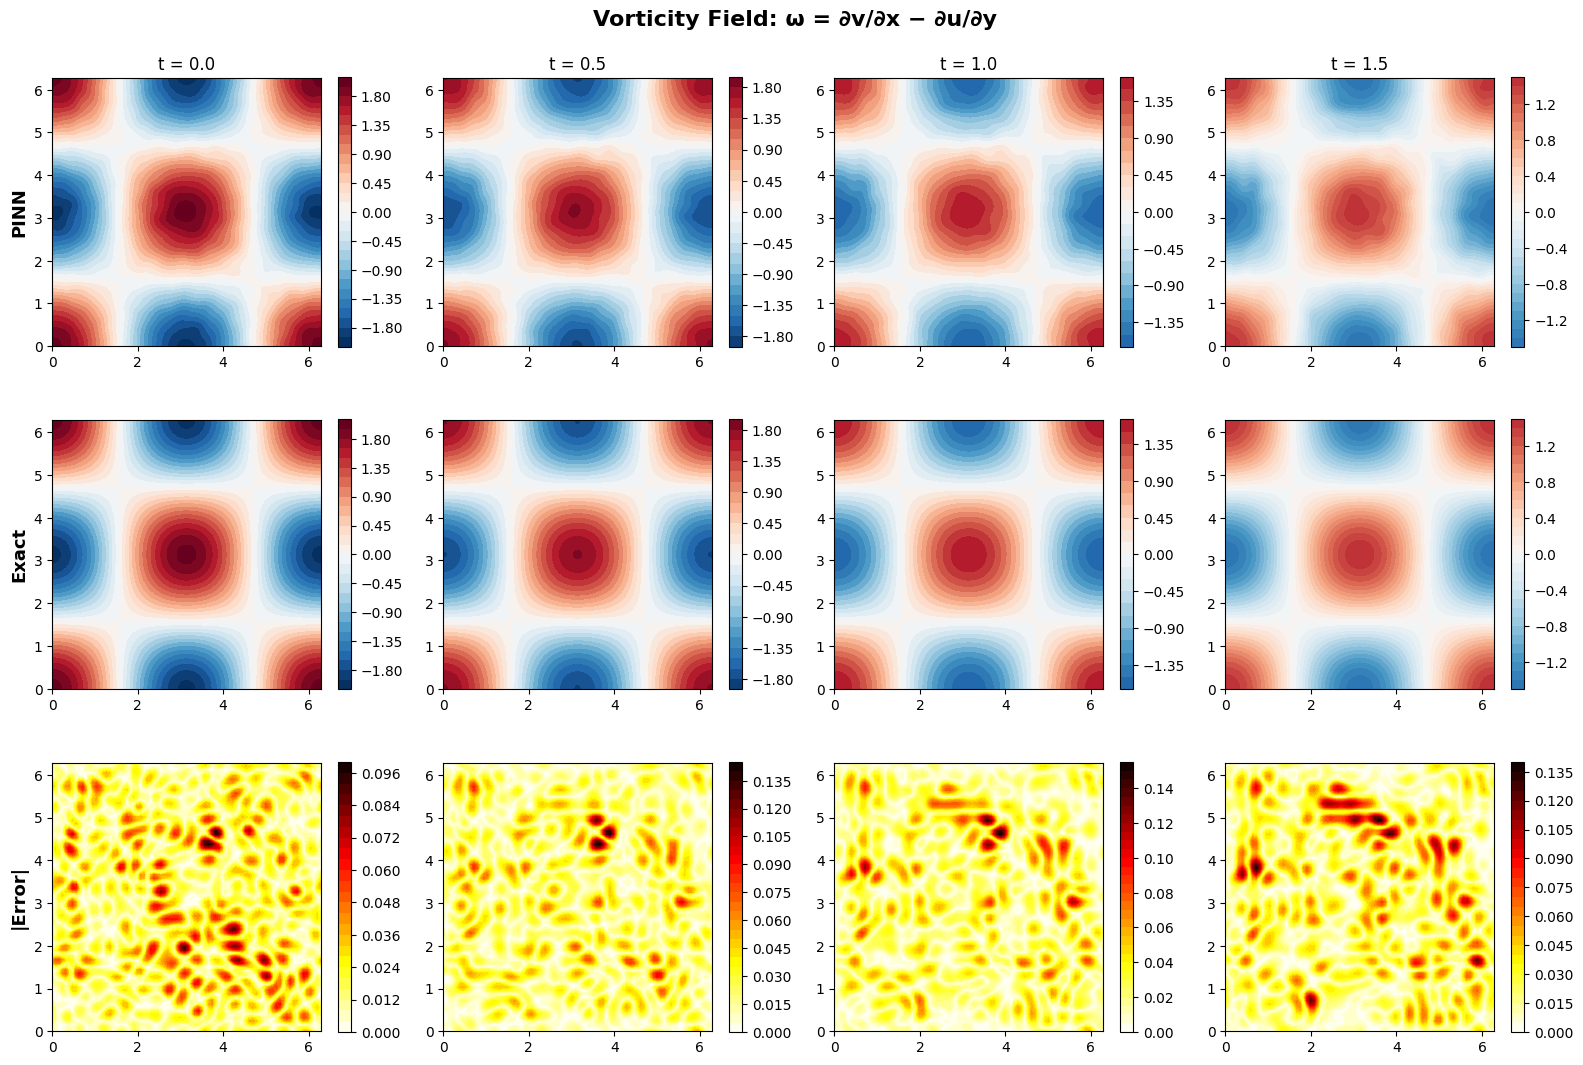

Saved: ns_tgv_vorticity.png

Computing temporal probes...
  Probe: Vortex center (π/2, π/2)
  Probe: Corner (0, 0)
  Probe: Saddle point (π, π/2)


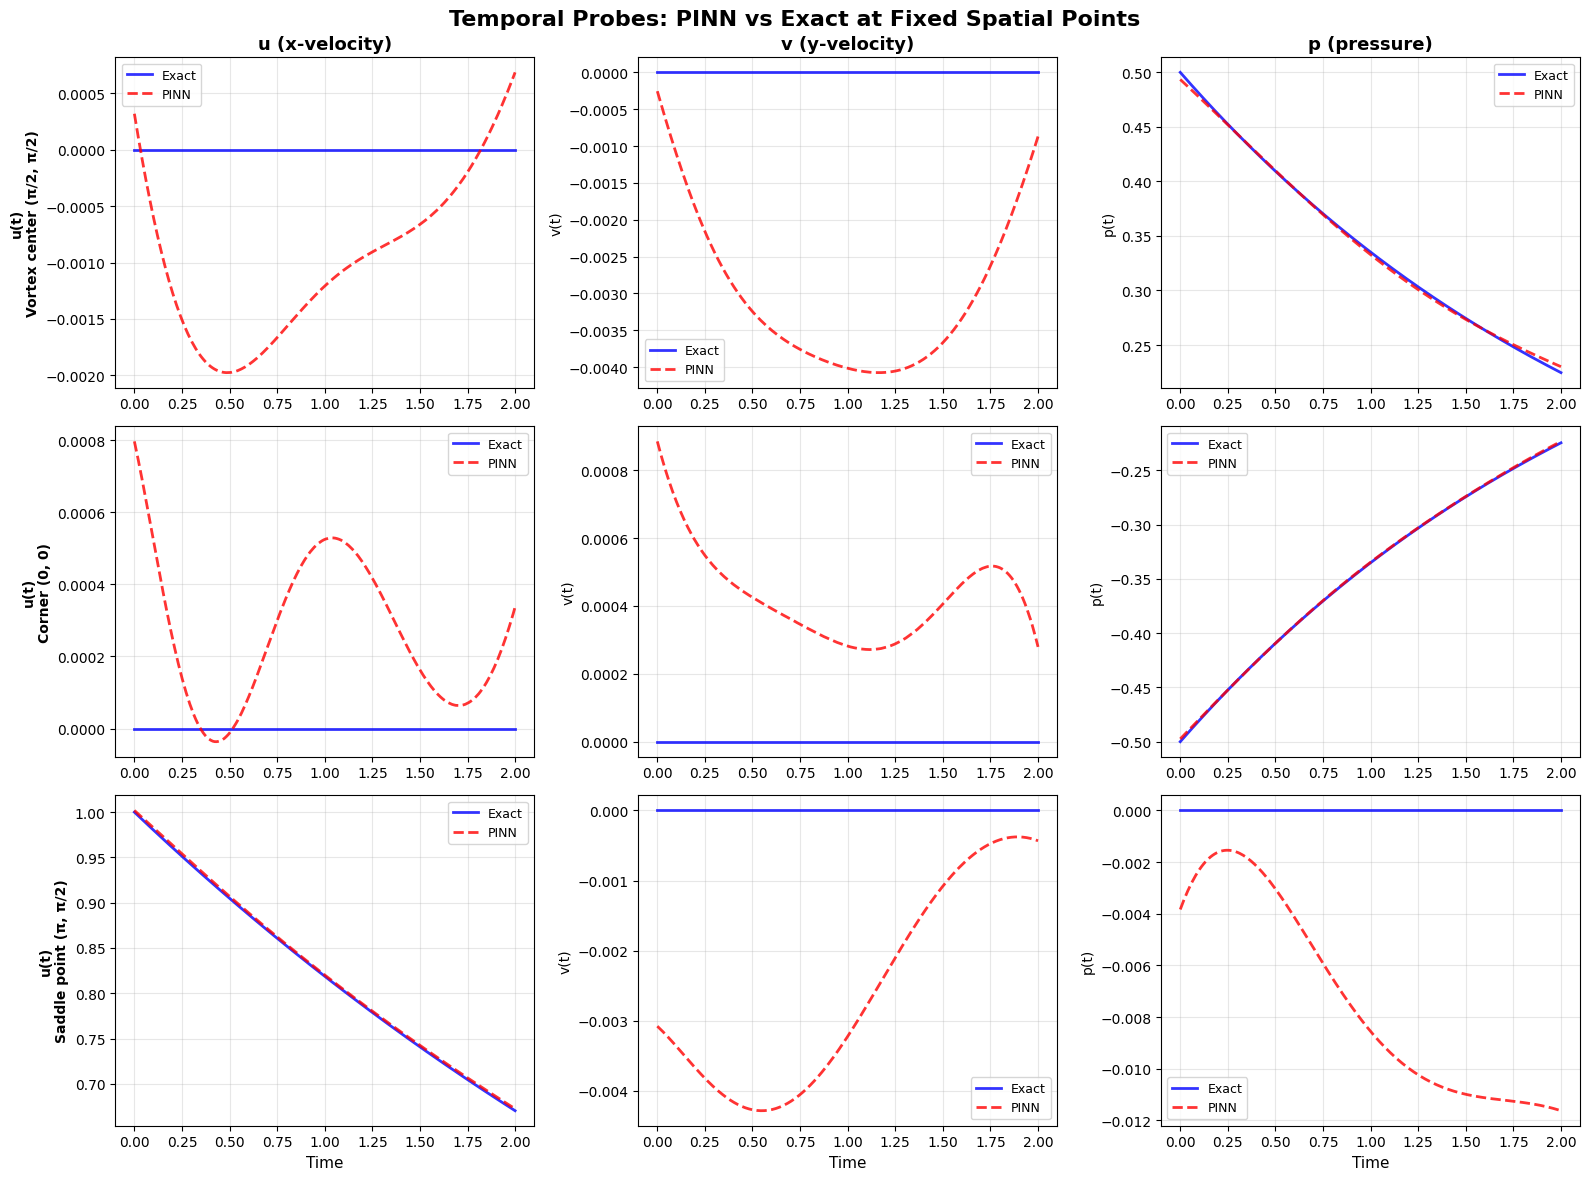

Saved: ns_tgv_temporal_probes.png

Computing line probes...


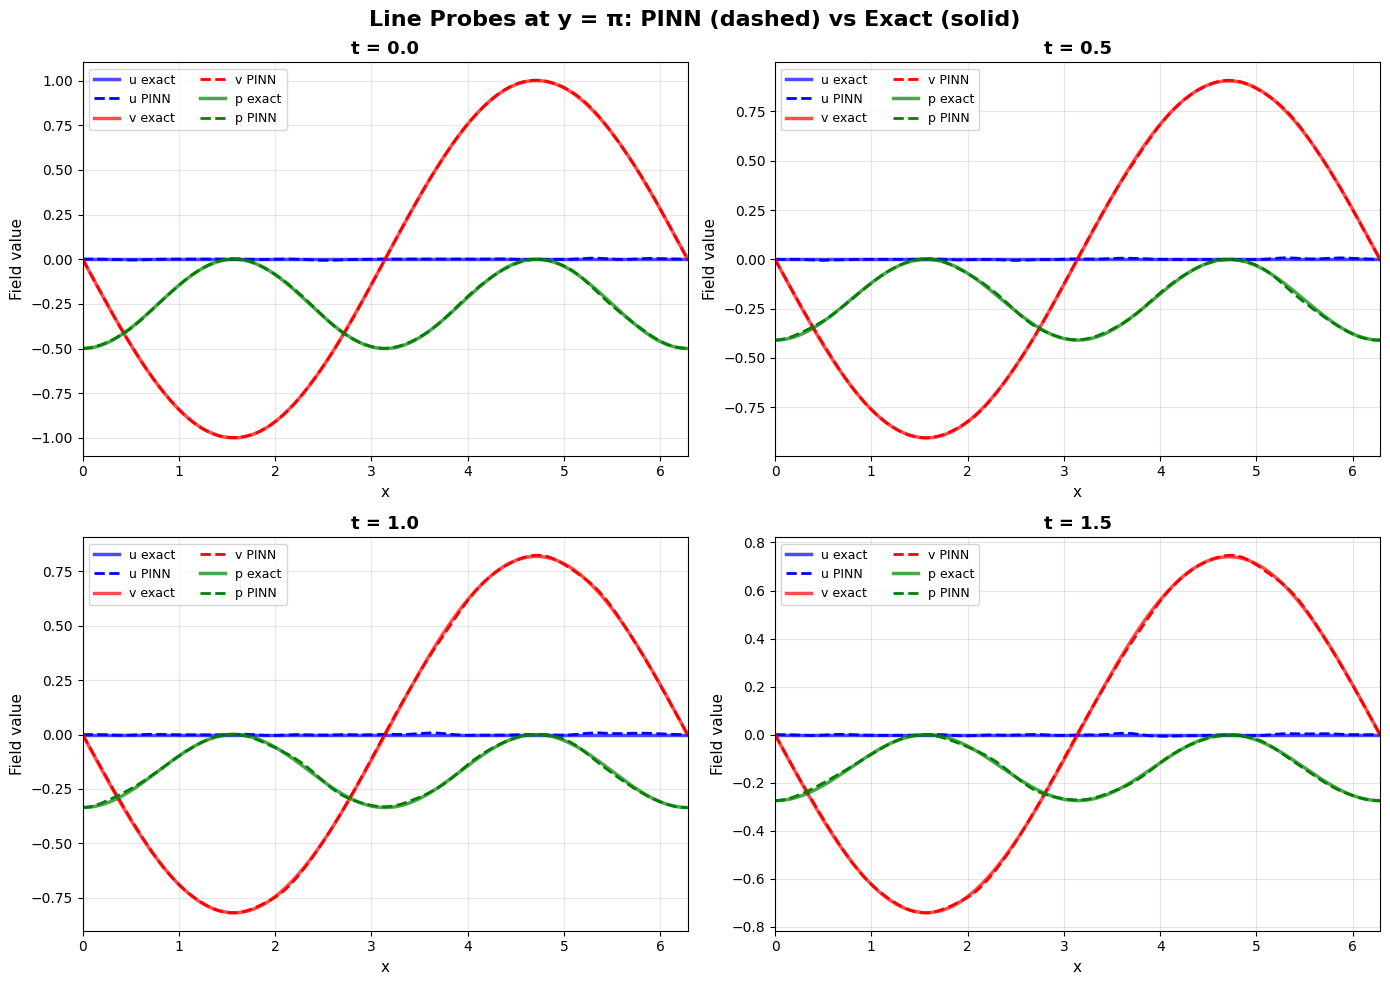

Saved: ns_tgv_line_probes.png

Done! Generated:
  1. ns_tgv_vorticity.png      — Vorticity pred vs exact vs error at 4 time slices
  2. ns_tgv_temporal_probes.png — u, v, p over time at 3 key spatial points
  3. ns_tgv_line_probes.png     — Line cuts at y=π showing all fields vs exact


In [3]:
"""
Professional CFD validation plots for NS TGV PINN
1. Vorticity field (predicted vs exact)
2. Temporal probes at key points
3. Line probes through the domain
Run AFTER training. Assumes: params, network, exact_solution, L, T_final, nu are defined.
"""
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

# ============ 1. VORTICITY FIELD ============
# Vorticity: omega = dv/dx - du/dy
# This is the quantity that tells you WHERE the fluid is spinning.
# For TGV exact vorticity: omega = 2*cos(x)*cos(y)*exp(-2*nu*t)

print("Computing vorticity fields...")

N_test = 80
x_test = jnp.linspace(0, L, N_test)
y_test = jnp.linspace(0, L, N_test)
xx, yy = jnp.meshgrid(x_test, y_test)
xx_flat = xx.reshape(-1, 1)
yy_flat = yy.reshape(-1, 1)
xx_np = np.array(xx)
yy_np = np.array(yy)

def compute_vorticity_single(params, t_val, x_val, y_val):
    """Compute vorticity omega = dv/dx - du/dy at a single point using the PINN."""
    def u_v_p(t, x, y):
        txy = jnp.array([[t, x, y]])
        return network(params, txy)[0]
    
    # Only need dv/dx and du/dy — use jacfwd on specific argnums
    J_x = jax.jacfwd(u_v_p, argnums=1)(t_val, x_val, y_val)  # d(u,v,p)/dx
    J_y = jax.jacfwd(u_v_p, argnums=2)(t_val, x_val, y_val)  # d(u,v,p)/dy
    
    dv_dx = J_x[1]  # v is output index 1, differentiated w.r.t. x
    du_dy = J_y[0]   # u is output index 0, differentiated w.r.t. y
    
    return dv_dx - du_dy

compute_vorticity_batch = jax.vmap(compute_vorticity_single, in_axes=(None, 0, 0, 0))

def exact_vorticity(t, x, y, nu):
    """Exact TGV vorticity: omega = 2*cos(x)*cos(y)*exp(-2*nu*t)"""
    return 2.0 * jnp.cos(x) * jnp.cos(y) * jnp.exp(-2 * nu * t)

# Plot vorticity at multiple time slices
time_slices = [0.0, 0.5, 1.0, 1.5]

fig1, axes1 = plt.subplots(3, len(time_slices), figsize=(16, 11))
fig1.suptitle('Vorticity Field: ω = ∂v/∂x − ∂u/∂y', fontsize=16, fontweight='bold')

# Get global color limits from t=0 exact
omega_max = 2.0  # max of exact vorticity at t=0

for col, t_val in enumerate(time_slices):
    print(f"  Computing vorticity at t = {t_val}...")
    tt_flat = jnp.ones(N_test * N_test) * t_val
    
    # PINN vorticity
    omega_pred = compute_vorticity_batch(params, tt_flat, xx_flat.ravel(), yy_flat.ravel())
    omega_pred_2d = np.array(omega_pred.reshape(N_test, N_test))
    
    # Exact vorticity
    omega_exact_2d = np.array(exact_vorticity(t_val, xx, yy, nu))
    
    # Error
    omega_error_2d = np.abs(omega_pred_2d - omega_exact_2d)
    
    # Predicted
    im0 = axes1[0, col].contourf(xx_np, yy_np, omega_pred_2d, levels=30,
                                   cmap='RdBu_r', vmin=-omega_max, vmax=omega_max)
    axes1[0, col].set_title(f't = {t_val}', fontsize=12)
    axes1[0, col].set_aspect('equal')
    plt.colorbar(im0, ax=axes1[0, col], shrink=0.8)
    
    # Exact
    im1 = axes1[1, col].contourf(xx_np, yy_np, omega_exact_2d, levels=30,
                                   cmap='RdBu_r', vmin=-omega_max, vmax=omega_max)
    axes1[1, col].set_aspect('equal')
    plt.colorbar(im1, ax=axes1[1, col], shrink=0.8)
    
    # Error
    im2 = axes1[2, col].contourf(xx_np, yy_np, omega_error_2d, levels=30, cmap='hot_r')
    axes1[2, col].set_aspect('equal')
    plt.colorbar(im2, ax=axes1[2, col], shrink=0.8)

# Row labels
axes1[0, 0].set_ylabel('PINN', fontsize=13, fontweight='bold')
axes1[1, 0].set_ylabel('Exact', fontsize=13, fontweight='bold')
axes1[2, 0].set_ylabel('|Error|', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('ns_tgv_vorticity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ns_tgv_vorticity.png")


# ============ 2. TEMPORAL PROBES ============
# Track u, v, p at specific points over time.
# This catches temporal drift that spatial snapshots miss.

print("\nComputing temporal probes...")

probe_points = [
    (jnp.pi / 2, jnp.pi / 2, 'Vortex center (π/2, π/2)'),
    (0.0, 0.0, 'Corner (0, 0)'),
    (jnp.pi, jnp.pi / 2, 'Saddle point (π, π/2)'),
]

n_time = 200
t_probe = jnp.linspace(0, T_final, n_time)

fig2, axes2 = plt.subplots(len(probe_points), 3, figsize=(16, 4 * len(probe_points)))
fig2.suptitle('Temporal Probes: PINN vs Exact at Fixed Spatial Points', 
              fontsize=16, fontweight='bold')

for row, (xp, yp, label) in enumerate(probe_points):
    print(f"  Probe: {label}")
    
    u_pred_t = []
    v_pred_t = []
    p_pred_t = []
    u_exact_t = []
    v_exact_t = []
    p_exact_t = []
    
    for tv in t_probe:
        # PINN prediction
        txy = jnp.array([[tv, xp, yp]])
        uvp = network(params, txy)[0]
        u_pred_t.append(float(uvp[0]))
        v_pred_t.append(float(uvp[1]))
        p_pred_t.append(float(uvp[2]))
        
        # Exact
        ue, ve, pe = exact_solution(tv, xp, yp, nu)
        u_exact_t.append(float(ue))
        v_exact_t.append(float(ve))
        p_exact_t.append(float(pe))
    
    t_np = np.array(t_probe)
    
    # u(t)
    axes2[row, 0].plot(t_np, u_exact_t, 'b-', linewidth=2, label='Exact', alpha=0.8)
    axes2[row, 0].plot(t_np, u_pred_t, 'r--', linewidth=2, label='PINN', alpha=0.8)
    axes2[row, 0].set_ylabel(f'u(t)\n{label}', fontsize=10, fontweight='bold')
    axes2[row, 0].legend(fontsize=9)
    axes2[row, 0].grid(True, alpha=0.3)
    
    # v(t)
    axes2[row, 1].plot(t_np, v_exact_t, 'b-', linewidth=2, label='Exact', alpha=0.8)
    axes2[row, 1].plot(t_np, v_pred_t, 'r--', linewidth=2, label='PINN', alpha=0.8)
    axes2[row, 1].set_ylabel('v(t)', fontsize=10)
    axes2[row, 1].legend(fontsize=9)
    axes2[row, 1].grid(True, alpha=0.3)
    
    # p(t)
    axes2[row, 2].plot(t_np, p_exact_t, 'b-', linewidth=2, label='Exact', alpha=0.8)
    axes2[row, 2].plot(t_np, p_pred_t, 'r--', linewidth=2, label='PINN', alpha=0.8)
    axes2[row, 2].set_ylabel('p(t)', fontsize=10)
    axes2[row, 2].legend(fontsize=9)
    axes2[row, 2].grid(True, alpha=0.3)

# Column titles
axes2[0, 0].set_title('u (x-velocity)', fontsize=13, fontweight='bold')
axes2[0, 1].set_title('v (y-velocity)', fontsize=13, fontweight='bold')
axes2[0, 2].set_title('p (pressure)', fontsize=13, fontweight='bold')

# x labels on bottom row only
for col in range(3):
    axes2[-1, col].set_xlabel('Time', fontsize=11)

plt.tight_layout()
plt.savefig('ns_tgv_temporal_probes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ns_tgv_temporal_probes.png")


# ============ 3. LINE PROBES ============
# Cut through the domain at fixed y, plot u(x) at multiple times.
# This reveals phase errors and amplitude drift that contour plots hide.

print("\nComputing line probes...")

N_line = 200
x_line = jnp.linspace(0, L, N_line)
y_fixed = jnp.pi  # Cut through middle of domain

fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle(f'Line Probes at y = π: PINN (dashed) vs Exact (solid)', 
              fontsize=16, fontweight='bold')

t_line_vals = [0.0, 0.5, 1.0, 1.5]

for idx, t_val in enumerate(t_line_vals):
    ax = axes3.flat[idx]
    
    # PINN predictions along the line
    txy_line = jnp.stack([
        jnp.ones(N_line) * t_val,
        x_line,
        jnp.ones(N_line) * y_fixed
    ], axis=1)  # (N_line, 3)
    
    uvp_line = network(params, txy_line)
    u_line_pred = np.array(uvp_line[:, 0])
    v_line_pred = np.array(uvp_line[:, 1])
    p_line_pred = np.array(uvp_line[:, 2])
    
    # Exact along the line
    u_ex = np.array(-jnp.cos(x_line) * jnp.sin(y_fixed) * jnp.exp(-2 * nu * t_val))
    v_ex = np.array(jnp.sin(x_line) * jnp.cos(y_fixed) * jnp.exp(-2 * nu * t_val))
    p_ex = np.array(-0.25 * (jnp.cos(2 * x_line) + jnp.cos(2 * y_fixed)) * jnp.exp(-4 * nu * t_val))
    
    x_np = np.array(x_line)
    
    ax.plot(x_np, u_ex, 'b-', linewidth=2.5, label='u exact', alpha=0.7)
    ax.plot(x_np, u_line_pred, 'b--', linewidth=2, label='u PINN')
    
    ax.plot(x_np, v_ex, 'r-', linewidth=2.5, label='v exact', alpha=0.7)
    ax.plot(x_np, v_line_pred, 'r--', linewidth=2, label='v PINN')
    
    ax.plot(x_np, p_ex, 'g-', linewidth=2.5, label='p exact', alpha=0.7)
    ax.plot(x_np, p_line_pred, 'g--', linewidth=2, label='p PINN')
    
    ax.set_title(f't = {t_val}', fontsize=13, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('Field value', fontsize=11)
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, float(L))

plt.tight_layout()
plt.savefig('ns_tgv_line_probes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ns_tgv_line_probes.png")


print("\nDone! Generated:")
print("  1. ns_tgv_vorticity.png      — Vorticity pred vs exact vs error at 4 time slices")
print("  2. ns_tgv_temporal_probes.png — u, v, p over time at 3 key spatial points")
print("  3. ns_tgv_line_probes.png     — Line cuts at y=π showing all fields vs exact")

## Compare analytical solution

    t |    u err % |    v err % |    p err %
-----------------------------------------------------------------
  0.0 |     0.432% |     0.410% |     1.171%
  0.5 |     0.585% |     0.599% |     1.890%
  1.0 |     0.791% |     0.812% |     2.252%
  1.5 |     0.976% |     0.965% |     2.719%


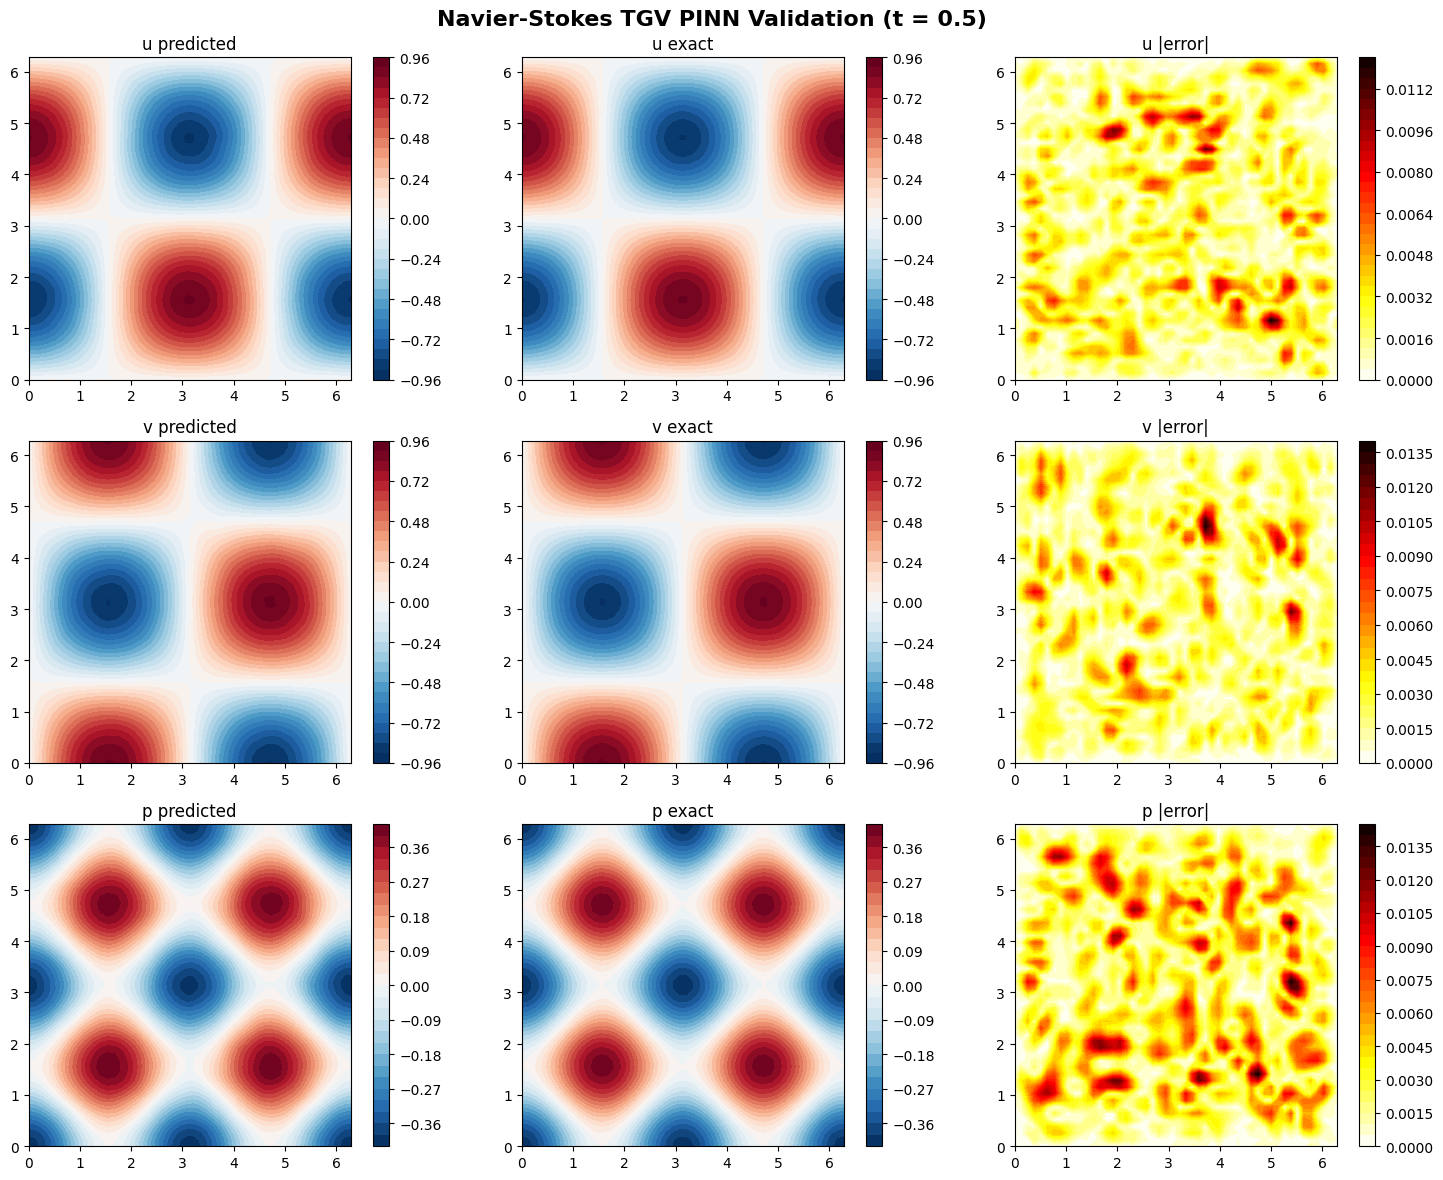

Saved: ns_tgv_validation.png


In [4]:
"""
Validation script for Navier-Stokes TGV PINN
Run this AFTER training. Assumes: params, network, exact_solution, L, nu are defined.
"""
import matplotlib.pyplot as plt
import jax.numpy as jnp

# ============ 1. QUANTITATIVE VALIDATION: Relative L2 errors ============

N_test = 50
x_test = jnp.linspace(0, L, N_test)
y_test = jnp.linspace(0, L, N_test)
xx, yy = jnp.meshgrid(x_test, y_test)
xx_flat = xx.reshape(-1, 1)  # (2500, 1)
yy_flat = yy.reshape(-1, 1)  # (2500, 1)

time_slices = [0.0, 0.5, 1.0, 1.5]

print("=" * 65)
print(f"{'t':>5} | {'u err %':>10} | {'v err %':>10} | {'p err %':>10}")
print("-" * 65)

for t_val in time_slices:
    tt_flat = jnp.ones_like(xx_flat) * t_val
    
    # Network prediction
    txy_test = jnp.concatenate([tt_flat, xx_flat, yy_flat], axis=1)  # (2500, 3)
    uvp_pred = network(params, txy_test)  # (2500, 3)
    
    u_pred = uvp_pred[:, 0]
    v_pred = uvp_pred[:, 1]
    p_pred = uvp_pred[:, 2]
    
    # Exact solution
    u_exact, v_exact, p_exact = exact_solution(tt_flat, xx_flat, yy_flat, nu)
    u_exact = u_exact.ravel()
    v_exact = v_exact.ravel()
    p_exact = p_exact.ravel()
    
    # Relative L2 errors: ||pred - exact|| / ||exact||
    u_err = jnp.linalg.norm(u_pred - u_exact) / jnp.linalg.norm(u_exact) * 100
    v_err = jnp.linalg.norm(v_pred - v_exact) / jnp.linalg.norm(v_exact) * 100
    p_err = jnp.linalg.norm(p_pred - p_exact) / jnp.linalg.norm(p_exact) * 100
    
    print(f"{t_val:>5.1f} | {u_err:>9.3f}% | {v_err:>9.3f}% | {p_err:>9.3f}%")

print("=" * 65)


# ============ 2. VISUAL VALIDATION: Predicted vs Exact at t=0.5 ============

t_plot = 0.5
tt_plot = jnp.ones_like(xx_flat) * t_plot

txy_plot = jnp.concatenate([tt_plot, xx_flat, yy_flat], axis=1)
uvp_plot = network(params, txy_plot)

u_exact_plot, v_exact_plot, p_exact_plot = exact_solution(tt_plot, xx_flat, yy_flat, nu)

fields = {
    'u': (uvp_plot[:, 0], u_exact_plot.ravel()),
    'v': (uvp_plot[:, 1], v_exact_plot.ravel()),
    'p': (uvp_plot[:, 2], p_exact_plot.ravel()),
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle(f'Navier-Stokes TGV PINN Validation (t = {t_plot})', fontsize=16, fontweight='bold')

for row, (name, (pred, exact)) in enumerate(fields.items()):
    pred_2d = pred.reshape(N_test, N_test)
    exact_2d = exact.reshape(N_test, N_test)
    error_2d = jnp.abs(pred_2d - exact_2d)
    
    # Shared color limits for pred vs exact
    vmin = min(float(pred_2d.min()), float(exact_2d.min()))
    vmax = max(float(pred_2d.max()), float(exact_2d.max()))
    
    # Predicted
    im0 = axes[row, 0].contourf(xx, yy, pred_2d, levels=30, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f'{name} predicted')
    axes[row, 0].set_aspect('equal')
    plt.colorbar(im0, ax=axes[row, 0])
    
    # Exact
    im1 = axes[row, 1].contourf(xx, yy, exact_2d, levels=30, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f'{name} exact')
    axes[row, 1].set_aspect('equal')
    plt.colorbar(im1, ax=axes[row, 1])
    
    # Absolute error
    im2 = axes[row, 2].contourf(xx, yy, error_2d, levels=30, cmap='hot_r')
    axes[row, 2].set_title(f'{name} |error|')
    axes[row, 2].set_aspect('equal')
    plt.colorbar(im2, ax=axes[row, 2])

plt.tight_layout()
plt.savefig('ns_tgv_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ns_tgv_validation.png")


# # ============ 3. LOSS CURVES ============
# # Assumes losses, losses_ic, losses_bc, losses_physics are defined from training

# fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Total loss (log scale)
# ax1.semilogy(losses)
# ax1.set_xlabel('Iteration')
# ax1.set_ylabel('Total Loss')
# ax1.set_title('Total Loss')
# ax1.grid(True, alpha=0.3)

# # Individual losses (log scale)
# ax2.semilogy(losses_ic, label='IC', alpha=0.8)
# ax2.semilogy(losses_bc, label='BC', alpha=0.8)
# ax2.semilogy(losses_physics, label='Physics', alpha=0.8)
# ax2.set_xlabel('Iteration')
# ax2.set_ylabel('Loss')
# ax2.set_title('Individual Losses')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('ns_tgv_losses.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved: ns_tgv_losses.png")